Auteur : BUSIDAN, Thibault

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

In [3]:
path="C:/Users/thiba/OneDrive/Documents/Master Aix-Marseille/Data Manipulation/Données CSV"
# Charger les tables de base
personnes = pd.read_csv(f'{path}/personnes.csv')
contrats = pd.read_csv(f'{path}/contrats.csv')
emplois = pd.read_csv(f'{path}/emplois.csv')
absences = pd.read_csv(f'{path}/absences.csv')
absences_types = pd.read_csv(f'{path}/absences_types.csv')
conges_rtt = pd.read_csv(f'{path}/conges_rtt.csv')

# Conversion des dates
contrats['debut'] = pd.to_datetime(contrats['debut'])
contrats['fin'] = pd.to_datetime(contrats['fin'])
absences['debut'] = pd.to_datetime(absences['debut'])
absences['fin'] = pd.to_datetime(absences['fin'])
conges_rtt['debut'] = pd.to_datetime(conges_rtt['debut'])
conges_rtt['fin'] = pd.to_datetime(conges_rtt['fin'])

print("Tables chargées :")
print(f"- Personnes: {len(personnes)} lignes")
print(f"- Contrats: {len(contrats)} lignes") 
print(f"- Emplois: {len(emplois)} lignes")
print(f"- Absences: {len(absences)} lignes")
print(f"- Types d'absences: {len(absences_types)} lignes")
print(f"- Congés/RTT: {len(conges_rtt)} lignes")

Tables chargées :
- Personnes: 3000 lignes
- Contrats: 4450 lignes
- Emplois: 299 lignes
- Absences: 2586 lignes
- Types d'absences: 23 lignes
- Congés/RTT: 9769 lignes


In [4]:
import glob
import os

def charger_temps_du_mensuel(annee=None, mois=None, path="C:/Users/thiba/OneDrive/Documents/Master Aix-Marseille/Data Manipulation/temps_du_plages/temps_du_plages"):
    """
    Charge les fichiers de temps dû mensuels.
    
    Args:
        annee: Année spécifique (None = toutes)
        mois: Mois spécifique (None = tous)
        path: Chemin des fichiers de temps dû (par défaut "../data/temps_du_plages")
    
    Returns:
        DataFrame: Données de temps dû consolidées
    """
    # Construire le pattern de fichier
    if annee and mois:
        pattern = f"{path}/temps_du_{annee}_{mois:02d}.csv"
    elif annee:
        pattern = f"{path}/temps_du_{annee}_*.csv"
    else:
        pattern = f"{path}/temps_du_*.csv"

    fichiers = glob.glob(pattern)
    
    if not fichiers:
        print(f"Aucun fichier trouvé avec le pattern: {pattern}")
        return pd.DataFrame()
    
    print(f"Chargement de {len(fichiers)} fichiers de temps dû...")
    
    dataframes = []
    for fichier in sorted(fichiers):
        try:
            # Compléter ici pour remplir la liste dataframes
            fc = pd.read_csv(fichier)
            for f in ['start', 'end']:
                if f in fc.columns:
                    fc[f] = pd.to_datetime(fc[f], errors='coerce')
            dataframes.append(fc)
        except Exception as e:
            print(f"  KO Erreur avec {fichier}: {e}")
    
    if dataframes:
        temps_du = pd.concat(dataframes, ignore_index=True)
        print(f"Total: {len(temps_du)} lignes de temps dû")
        return temps_du
    else:
        return pd.DataFrame()

# Charger quelques mois pour les exemples
temps_du = charger_temps_du_mensuel()

Chargement de 12 fichiers de temps dû...
Total: 170134 lignes de temps dû


In [5]:
def creer_table_contrats_enrichie():
    """
    Crée une table enrichie des contrats avec infos personnes et emplois.
    
    Returns:
        DataFrame: Contrats avec toutes les informations contextuelles
    """
    # Jointure contrats -> personnes et emplois
    resultat = pd.merge(
    contrats, 
    personnes,
    #on='id',        # Colonne de jointure commune
    how='inner',                 # Type de jointure
    left_on='id_pers',        # Si noms différents
    right_on='id',       # Si noms différents
)
    # Compléter ici pour créer la table contrats_enrichis
    contrats_enrichis = pd.merge(
    resultat, 
    emplois,
    #on='id',        # Colonne de jointure commune
    how='inner',                 # Type de jointure
    left_on='id_emploi',        # Si noms différents
    right_on='id',       # Si noms différents
)
    # Nettoyer les colonnes en doublon
    colonnes_a_garder = [
        'id', 'debut', 'fin', 'type', 'part_temps',
        'nom', 'prénom', 'date de naissance', 'genre',
        'libellé', 'catégorie', 'rythme',
        'id_pers', 'id_emploi'
    ]
    
    contrats_enrichis = contrats_enrichis[colonnes_a_garder]
    
    # Calculer l'âge et l'ancienneté
    contrats_enrichis['date de naissance'] = pd.to_datetime(contrats_enrichis['date de naissance'])
    contrats_enrichis['age'] = (contrats_enrichis['fin'] - contrats_enrichis['date de naissance']).dt.days # Corriger ici
    contrats_enrichis['age'] = contrats_enrichis['age']/365.25
    contrats_enrichis['anciennete_jours'] = (contrats_enrichis['fin'] - contrats_enrichis['debut']).dt.days# Corriger ici
    contrats_enrichis['anciennete_annees'] = contrats_enrichis['anciennete_jours']/365.25 # Corriger ici

    return contrats_enrichis

# Créer la table enrichie
contrats_enrichis = creer_table_contrats_enrichie()

print("Table contrats enrichie créée:")
print(f"Dimensions: {contrats_enrichis.shape}")
print("\nPremières lignes:")
print(contrats_enrichis[['nom', 'prénom', 'libellé', 'catégorie', 'type', 'age']].head())

Table contrats enrichie créée:
Dimensions: (4450, 17)

Premières lignes:
        nom    prénom                                            libellé  \
0   Alvarez     Maria                              Infirmier réanimation   
1  Belkacem  Ibrahima                                 Interprète médical   
2  Belkacem  Ibrahima                                 Interprète médical   
3   Nikolić      Hugo            Infirmier d'hémovigilance / transfusion   
4  Youssouf    Miguel  Chargé des affaires médicales (planning pratic...   

          catégorie type        age  
0  Soins infirmiers  cdi  19.550992  
1     Administratif  cdi  18.617385  
2     Administratif  cdi  19.362081  
3  Soins infirmiers  cdd  18.962355  
4     Administratif  cdi        NaN  


In [6]:
def enrichir_absences():
    """
    Enrichit les absences avec les types et informations contrats.
    
    Returns:
        DataFrame: Absences avec descriptions complètes
    """
    # Jointure absences -> types d'absences
    absences_typees = pd.DataFrame()  # Corriger ici 
    absences_typees = pd.merge(
    absences, 
    absences_types,
    on='code',        # Colonne de jointure commune
    how='inner',                 # Type de jointure
    suffixes=('', '_y')
    )
    absences_typees = absences_typees[[c for c in absences_typees.columns if not c.endswith('_y')]]
    # Jointure avec la vue contrats enrichie
    absences_enrichies = pd.DataFrame()  # Corriger ici
    absences_enrichies = pd.merge(absences_typees, contrats_enrichis, how='inner', left_on = 'id_contrat',
                                  right_on = 'id', suffixes=('', '_contrat'))
    # Sélectionner les colonnes utiles
    colonnes_finales = [
        'id', 'id_contrat', 'debut', 'fin', 'jours_ouvres',
        'code', 'libellé', 'libellé_contrat', 'famille', 'type', 'type_contrat',
        'nom', 'prénom', 'catégorie', 'age'
    ]
    
    # Renommer pour clarifier
    absences_enrichies = absences_enrichies[colonnes_finales].rename(columns={
        'libellé': 'libellé_absence',
        'type': 'type_absence'
    })
    absences_enrichies = absences_enrichies.loc[:,~absences_enrichies.columns.duplicated()].copy()
    return absences_enrichies

absences_enrichies = enrichir_absences()

print("Absences enrichies:")
print(f"Dimensions: {absences_enrichies.shape}")
print("\nExemple d'absences par type:")
print(absences_enrichies.groupby('libellé_absence').size().sort_values(ascending=False).head())
print(absences_enrichies)

Absences enrichies:
Dimensions: (4944, 15)

Exemple d'absences par type:
libellé_absence
Maladie                4122
Accident de travail     295
Enfant malade           244
Mariage/PACS             92
Déménagement             68
dtype: int64
       id  id_contrat      debut        fin  jours_ouvres code  \
0       1           5 2024-10-07 2024-10-13             5  MAL   
1       1           5 2024-10-07 2024-10-13             5  MAL   
2       1           5 2024-10-07 2024-10-13             5  MAL   
3       1           5 2024-10-07 2024-10-13             5  MAL   
4       1           5 2024-10-07 2024-10-13             5  MAL   
...   ...         ...        ...        ...           ...  ...   
4939  335         299 2025-08-17 2025-08-22             5  MAL   
4940  335         299 2025-08-17 2025-08-22             5  MAL   
4941  335         299 2025-08-17 2025-08-22             5  MAL   
4942  335         299 2025-08-17 2025-08-22             5  MAL   
4943  335         299 2025-08-17

In [7]:
def ajouter_identifiant_unique(temps_du):
    """
    Ajoute une colonne d'identifiant unique à la table des temps dû.
    
    Args:
        temps_du (DataFrame): Table des temps dû.
    
    Returns:
        DataFrame: Table des temps dû avec identifiant unique.
    """
    temps_du['id_temps_du'] = temps_du.index + 1 # Corriger ici
    return temps_du
temps_du = ajouter_identifiant_unique(temps_du)
print(temps_du)

           mois  id_pers  id_contrat  id_emploi  id_temps plage_type  \
0       2024-09        4           5        216       309    forfait   
1       2024-09        4           5        216       309    forfait   
2       2024-09        4           5        216       309    forfait   
3       2024-09        4           5        216       309    forfait   
4       2024-09        4           5        216       309    forfait   
...         ...      ...         ...        ...       ...        ...   
170129  2025-08     3000        4450         43        87       nuit   
170130  2025-08     3000        4450         43        87       nuit   
170131  2025-08     3000        4450         43        87       nuit   
170132  2025-08     3000        4450         43        87       nuit   
170133  2025-08     3000        4450         43        87       nuit   

                     start                 end  duree_heures   unite  \
0      2024-09-02 09:00:00 2024-09-02 17:00:00          8.00   

In [8]:
def joindre_temps_absences(temps_du, absences):
    """
    Jointure entre les temps dû et les absences.

    Args:
        temps_du (DataFrame): Table des temps dû.
        absences (DataFrame): Table des absences.

    Returns:
        DataFrame: Table des temps dû pendant les absences.
    """
    # Jointure temps_du et absences sur l'identifiant de contrat
    jointure = pd.DataFrame()  # Corriger ici
    jointure = pd.merge(temps_du, absences, on='id_contrat', how='inner', suffixes = ('', '_abs'))
    # Filtrer les périodes de temps se chevauchant
    temps_absences = jointure[(jointure['start']<=jointure['fin']) & (jointure['end']>=jointure['debut'])]

    return temps_absences

temps_absences = joindre_temps_absences(temps_du, absences)

In [9]:
def enrichir_temps_du(temps_du, temps_absences):
    """
    Enrichit la table des temps dû avec une colonne d'absence.

    Args:
        temps_du (DataFrame): Table des temps dû.
        temps_absences (DataFrame): Table des temps dû pendant les absences.

    Returns:
        DataFrame: Table des temps dû enrichie.
    """
    temps_du['absence'] = np.zeros(len(temps_du))
    ids_abs = temps_absences['id_contrat'].unique()
    temps_du.loc[temps_du['id_contrat'].isin(ids_abs), 'absence'] = 1 # Corriger ici
    return temps_du

temps_du = enrichir_temps_du(temps_du, temps_absences)
print(temps_du)

           mois  id_pers  id_contrat  id_emploi  id_temps plage_type  \
0       2024-09        4           5        216       309    forfait   
1       2024-09        4           5        216       309    forfait   
2       2024-09        4           5        216       309    forfait   
3       2024-09        4           5        216       309    forfait   
4       2024-09        4           5        216       309    forfait   
...         ...      ...         ...        ...       ...        ...   
170129  2025-08     3000        4450         43        87       nuit   
170130  2025-08     3000        4450         43        87       nuit   
170131  2025-08     3000        4450         43        87       nuit   
170132  2025-08     3000        4450         43        87       nuit   
170133  2025-08     3000        4450         43        87       nuit   

                     start                 end  duree_heures   unite  \
0      2024-09-02 09:00:00 2024-09-02 17:00:00          8.00   

In [10]:
def continuer_enrichir_temps_du(temps_du, absences_enrichies, contrats_enrichis):
    """
    Enrichit la table des temps dû avec des informations supplémentaires pour l'analyse.

    Args:
        temps_du (DataFrame): Table des temps dû avec colonne absence.
        absences_enrichies (DataFrame): Table des absences enrichies.
        contrats_enrichis (DataFrame): Table des contrats enrichis.

    Returns:
        DataFrame: Table des temps dû enrichie avec toutes les variables d'analyse.
    """
    # Jointure gauche temps_du avec contrats pour récupérer type_contrat, catégorie et age
    temps_du_enrichi = pd.DataFrame()
    temps_du_enrichi = pd.merge(temps_du, contrats_enrichis, on='id_pers', how='left', suffixes = ('', '_y'))
    colonnes_finales = ['mois', 'id_pers', 'id_contrat', 'id_emploi', 'id_temps', 'plage_type', 
                        'start', 'end', 'duree_heures', 'unite', 'quota_source',  'id_temps_du', 
                        'absence', 'type', 'catégorie', 'age']
    temps_du_enrichi = temps_du_enrichi[colonnes_finales].rename(columns={'type' : 'type_contrat'})
    # Ajouter la colonne mois
    temps_du_enrichi['mois'] = np.ones(len(temps_du_enrichi), dtype=int)  # Corriger ici
    temps_du_enrichi['mois'] = temps_du_enrichi['end'].dt.to_period('M')
    # Ajouter la tranche d'âge
    def calculer_tranche_age(age):
        # Compléter et corriger ici
        if pd.isna(age):
            return 'Non défini'
        if age < 20:
            return 'Moins de 20 ans'
        elif age < 30:
            return '20-30 ans'
        elif age < 40:
            return '30-40 ans'
        elif age < 50:
            return '40-50 ans'
        elif age < 60:
            return '50-60 ans'
        else:
            return '60 ans et plus'
        
    
    temps_du_enrichi['tranche_age'] = temps_du_enrichi['age'].apply(calculer_tranche_age)
    # Jointure avec absences enrichies pour récupérer famille et type_absence
    temps_du_avec_absences = pd.DataFrame()  # Corriger ici
    temps_du_avec_absences = pd.merge(temps_du_enrichi, absences_enrichies, on='id_contrat', how='left', suffixes =('', '_y'))
    
    # Filtrer pour ne garder famille et type_absence que si chevauchement temporel
    chevauchement = ((temps_du_avec_absences['start'] <= temps_du_avec_absences['fin']) & (temps_du_avec_absences['end'] >= temps_du_avec_absences['debut']))
    temps_du_avec_absences.loc[~chevauchement, ['famille', 'type_absence']]
    colonnes_finales = ['mois', 'id_pers', 'id_contrat', 'id_emploi', 'id_temps', 'plage_type', 
                        'start', 'end', 'duree_heures', 'unite', 'quota_source',  'id_temps_du', 
                        'absence', 'type_contrat', 'catégorie', 'age', 'famille', 'type_absence', 'tranche_age']
    temps_du_avec_absences = temps_du_avec_absences[colonnes_finales]
    return temps_du_avec_absences

temps_du = continuer_enrichir_temps_du(temps_du, absences_enrichies, contrats_enrichis)

In [11]:
# Agrégation des dénominateurs (total temps dû)
variables_groupby = ['mois', 'famille', 'type_absence', 'type_contrat', 'catégorie', 'tranche_age']

# Remplacer les NaN par 'Aucune' pour les colonnes liées aux absences
temps_du_clean = temps_du.fillna({
    'famille': 'Aucune', 
    'type_absence': 'Aucune'
})

denominateurs = 0 # Corriger ici
denominateurs = temps_du_clean.groupby(variables_groupby, dropna=False)['duree_heures'].sum().reset_index()
denominateurs.rename(columns={'duree_heures': 'temps_du_total'}, inplace=True)

# Agrégation des numérateurs (temps dû pendant absences)
numerateurs = 0 # Corriger ici
df = temps_du_clean[temps_du_clean['absence'] > 0]
numerateurs = df.groupby(variables_groupby, dropna=False)['absence'].sum().reset_index()
numerateurs.rename(columns={'absence': 'temps_absence_total'}, inplace=True)
# Jointure pour obtenir numérateurs et dénominateurs
taux_absenteisme_data = pd.DataFrame()  # Corriger ici
taux_absenteisme_data = pd.merge(
    denominateurs,
    numerateurs,
    on=variables_groupby,
    how='left'
)

# Remplacer les NaN dans les numérateurs par 0 (pas d'absence)
taux_absenteisme_data['temps_absence_total'] = taux_absenteisme_data['temps_absence_total'].fillna(0)
taux_absenteisme_data['taux_absence'] = (taux_absenteisme_data['temps_absence_total']/taux_absenteisme_data['temps_du_total'])*100
print(f"Table d'analyse créée avec {len(taux_absenteisme_data)} lignes")
print("Premières lignes:")
print(taux_absenteisme_data.head())

Table d'analyse créée avec 2761 lignes
Premières lignes:
      mois              famille         type_absence type_contrat  \
0  2024-09  Absences non payées               Divers          cdi   
1  2024-09       Accidentologie  Accident de travail          cdd   
2  2024-09       Accidentologie  Accident de travail          cdd   
3  2024-09       Accidentologie  Accident de travail          cdd   
4  2024-09       Accidentologie  Accident de travail          cdi   

               catégorie tranche_age  temps_du_total  temps_absence_total  \
0  Administratif/médical  Non défini         4335.00                578.0   
1                Médical   20-30 ans         2448.00                306.0   
2                Médical   30-40 ans         2448.00                306.0   
3    Techniques/bâtiment   40-50 ans          660.48                 86.0   
4  Administratif/médical   20-30 ans        11424.00               1428.0   

   taux_absence  
0     13.333333  
1     12.500000  
2     12.50

Jusqu'a present on a repris notre TP4 pour creer notre table de taux d'absenteisme.

In [12]:
def calculer_taux_absenteisme_mois_famille(taux_absenteisme_data):
    """
    Calcule les taux d'absentéisme par mois et famille d'absence.
    
    Args:
        taux_absenteisme_data (DataFrame): Données agrégées avec numérateurs et dénominateurs.
    
    Returns:
        DataFrame: Tableau croisé dynamique avec taux d'absentéisme (%).
    """
    # Agréger par mois et famille d'absence (sommer sur les autres dimensions)
    resume_mois_famille = pd.DataFrame()  # Corriger ici
    resume_mois_famille = (taux_absenteisme_data.groupby(['mois', 'famille'], dropna=False)[['temps_absence_total', 'temps_du_total']].sum().reset_index())
    # Calculer le taux d'absentéisme en pourcentage
    resume_mois_famille['taux_absenteisme'] = np.zeros(len(resume_mois_famille))  # Corriger ici
    resume_mois_famille['taux_absenteisme'] = (resume_mois_famille['temps_absence_total'] / resume_mois_famille['temps_du_total']) * 100
    # Créer un tableau croisé dynamique
    tableau_croise = pd.DataFrame()  # Corriger ici
    tableau_croise = resume_mois_famille.pivot_table(index='mois', columns='famille', values='taux_absenteisme', fill_value=0)
    return tableau_croise

# Exemple d'utilisation
exemple_taux = calculer_taux_absenteisme_mois_famille(taux_absenteisme_data)
print("Taux d'absentéisme par mois et famille d'absence (%):")
print(exemple_taux.round(2))

Taux d'absentéisme par mois et famille d'absence (%):
famille  Absences non payées  Accidentologie  Aucune  Autres  Maladie  \
mois                                                                    
2024-09                13.33           12.11    9.41   13.33    12.28   
2024-10                13.33           12.13    9.49   13.33    12.25   
2024-11                13.33           12.14    9.32   13.33    12.24   
2024-12                13.33           12.08    9.49   13.33    12.27   
2025-01                13.33           12.13    9.42   13.33    12.21   
2025-02                13.33           12.12    9.32   13.33    12.09   
2025-03                13.33           12.12    9.49   13.33    12.29   
2025-04                13.33           12.15    9.41   13.33    12.30   
2025-05                13.33           12.09    9.31   13.33    12.17   
2025-06                13.33           12.14    9.39   13.33    12.28   
2025-07                13.33           12.15    9.46   13.33    12.26 

In [13]:
def calculer_taux_absenteisme_mois_service(taux_absenteisme_data):
    """
    Calcule les taux d'absentéisme par mois et service d'absence.
    
    Args:
        taux_absenteisme_data (DataFrame): Données agrégées avec numérateurs et dénominateurs.
    
    Returns:
        DataFrame: Tableau croisé dynamique avec taux d'absentéisme (%).
    """
    # Agréger par mois et service d'absence (sommer sur les autres dimensions)
    resume_mois_service = pd.DataFrame()  # Corriger ici
    resume_mois_service = (taux_absenteisme_data.groupby(['mois', 'catégorie'], dropna=False)[['temps_absence_total', 'temps_du_total']].sum().reset_index())
    # Calculer le taux d'absentéisme en pourcentage
    resume_mois_service['taux_absenteisme'] = np.zeros(len(resume_mois_service))  # Corriger ici
    resume_mois_service['taux_absenteisme'] = (resume_mois_service['temps_absence_total'] / resume_mois_service['temps_du_total']) * 100
    # Créer un tableau croisé dynamique
    tableau_croise = pd.DataFrame()  # Corriger ici
    tableau_croise = resume_mois_service.pivot_table(index='mois', columns='catégorie', values='taux_absenteisme', fill_value=0)
    return tableau_croise

# Exemple d'utilisation
exemple_taux = calculer_taux_absenteisme_mois_service(taux_absenteisme_data)
print("Taux d'absentéisme par mois et service d'absence (%):")
print(exemple_taux.round(2))

Taux d'absentéisme par mois et service d'absence (%):
catégorie  Administratif  Administratif/médical  Biomédical  Bloc opératoire  \
mois                                                                           
2024-09            11.19                  12.75        7.92            11.21   
2024-10            11.34                  12.77        7.96            11.25   
2024-11            11.16                  12.77        7.99            11.18   
2024-12            11.27                  12.78        7.93            11.16   
2025-01            11.31                  12.77        8.01            11.21   
2025-02            11.30                  12.76        7.94            10.81   
2025-03            11.27                  12.78        7.93            11.22   
2025-04            11.19                  12.75        7.92            11.28   
2025-05            11.18                  12.79        8.02            11.04   
2025-06            11.19                  12.76        7.95       

In [14]:
def calculer_taux_absenteisme_age_famille(taux_absenteisme_data):
    """
    Calcule les taux d'absentéisme par age et famille d'absence.
    
    Args:
        taux_absenteisme_data (DataFrame): Données agrégées avec numérateurs et dénominateurs.
    
    Returns:
        DataFrame: Tableau croisé dynamique avec taux d'absentéisme (%).
    """
    # Agréger par age et famille d'absence (sommer sur les autres dimensions)
    resume_mois_famille = pd.DataFrame()  # Corriger ici
    resume_mois_famille = (taux_absenteisme_data.groupby(['tranche_age', 'famille'], dropna=False)[['temps_absence_total', 'temps_du_total']].sum().reset_index())
    # Calculer le taux d'absentéisme en pourcentage
    resume_mois_famille['taux_absenteisme'] = np.zeros(len(resume_mois_famille))
    resume_mois_famille['taux_absenteisme'] = (resume_mois_famille['temps_absence_total'] / resume_mois_famille['temps_du_total']) * 100
    # Créer un tableau croisé dynamique
    tableau_croise = pd.DataFrame()  # Corriger ici
    tableau_croise = resume_mois_famille.pivot_table(index='tranche_age', columns='famille', values='taux_absenteisme', fill_value=0)
    return tableau_croise

# Exemple d'utilisation
exemple_taux = calculer_taux_absenteisme_age_famille(taux_absenteisme_data)
print("Taux d'absentéisme par age et famille d'absence (%):")
print(exemple_taux)

Taux d'absentéisme par age et famille d'absence (%):
famille          Absences non payées  Accidentologie    Aucune     Autres  \
tranche_age                                                                 
20-30 ans                   0.000000       12.228123  9.792899   0.000000   
30-40 ans                   0.000000       11.150345  9.579185   0.000000   
40-50 ans                   0.000000       13.020833  9.495819   0.000000   
50-60 ans                   0.000000        0.000000  9.691795   0.000000   
60 ans et plus              0.000000        0.000000  8.727432   0.000000   
Moins de 20 ans             0.000000       13.020833  9.536780   0.000000   
Non défini                 13.814905       12.241116  9.250551  13.814905   

famille            Maladie  Événements familiaux  
tranche_age                                       
20-30 ans        12.178418             13.265213  
30-40 ans        12.787478             10.601841  
40-50 ans        13.020833              0.000000 

In [15]:
# Calcul des KPI
# Taux global (pondéré par jours_travailles)
taux_global = (taux_absenteisme_data['temps_absence_total'].sum()/taux_absenteisme_data['temps_du_total'].sum())*100
print(f"Taux d'absentéisme global : {taux_global:.2f}%")

# Taux par service (moyenne pondérée sur la période)
taux_par_service = (taux_absenteisme_data.groupby('catégorie').apply(lambda g: (g['temps_absence_total'].sum()/g['temps_du_total'].sum())*100)
                    .reset_index(name='taux_absenteisme'))
taux_par_service = taux_par_service.sort_values('taux_absenteisme', ascending=False).reset_index(drop=True)
print(f"Taux d'absentéisme par service (période entière) : {taux_par_service:}%")

# Taux par mois (global)
taux_par_mois = (taux_absenteisme_data.groupby('mois').apply(lambda g: (g['temps_absence_total'].sum()/g['temps_du_total'].sum())*100)
                 .reset_index(name='taux_absenteisme'))
taux_par_mois['mois'] = taux_par_mois['mois'].dt.strftime('%Y-%m')
print(f"Taux d'absentéisme par mois : {taux_par_mois:}%")

# Taux par famille (global)
taux_par_famille = (taux_absenteisme_data.groupby('famille').apply(lambda g: (g['temps_absence_total'].sum()/g['temps_du_total'].sum())*100)
                    .reset_index(name='taux_absenteisme'))
taux_par_famille = taux_par_famille.sort_values('taux_absenteisme', ascending=False).reset_index(drop=True)
print(f"Taux d'absentéisme par motif/famille d'absence (période entière) : {taux_par_famille:}%")
# Taux par tranche d'age (global)
taux_par_age = (taux_absenteisme_data.groupby('tranche_age').apply(lambda g: (g['temps_absence_total'].sum()/g['temps_du_total'].sum())*100)
                    .reset_index(name='taux_absenteisme'))
print(f"Taux d'absentéisme par tranche d'age (période entière) : {taux_par_age:}%")

Taux d'absentéisme global : 11.80%
Taux d'absentéisme par service (période entière) :                 catégorie  taux_absenteisme
0               Pharmacie         15.000822
1    Information médicale         13.779336
2           Psycho-social         13.749620
3             Laboratoire         13.380324
4             Rééducation         13.252425
5   Administratif/médical         13.127489
6     Techniques/bâtiment         13.054548
7                 Médical         12.842235
8               Juridique         11.963171
9           Administratif         11.714053
10             Logistique         11.183282
11              Direction         10.817376
12                Qualité         10.738768
13       Soins infirmiers         10.720788
14        Bloc opératoire         10.622254
15              Recherche          8.172954
16             Biomédical          8.056892
17               Imagerie          7.626541
18             Maïeutique          7.580515
19       Pédiatrie/néonat         

C:\Users\thiba\AppData\Local\Temp\ipykernel_27588\2851322566.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  taux_par_service = (taux_absenteisme_data.groupby('catégorie').apply(lambda g: (g['temps_absence_total'].sum()/g['temps_du_total'].sum())*100)
C:\Users\thiba\AppData\Local\Temp\ipykernel_27588\2851322566.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  taux_par_mois = (taux_absenteisme_data.groupby('mo

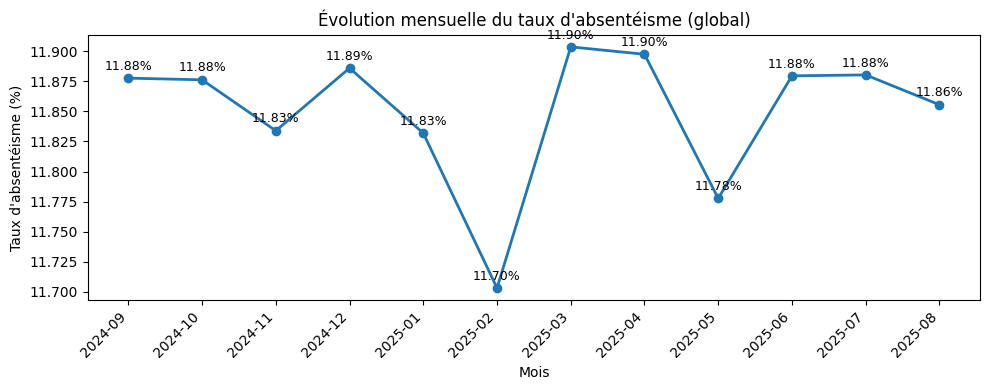

In [16]:
# Graphique 1 : évolution temporelle du taux global
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(taux_par_mois['mois'], taux_par_mois['taux_absenteisme'], marker='o', linewidth=2)
ax.set_title('Évolution mensuelle du taux d\'absentéisme (global)')
ax.set_ylabel('Taux d\'absentéisme (%)')
ax.set_xlabel('Mois')
plt.xticks(rotation=45, ha='right')
for x,y in zip(taux_par_mois['mois'], taux_par_mois['taux_absenteisme']):
    ax.annotate(f"{y:.2f}%", (x,y), textcoords="offset points", xytext=(0,6), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

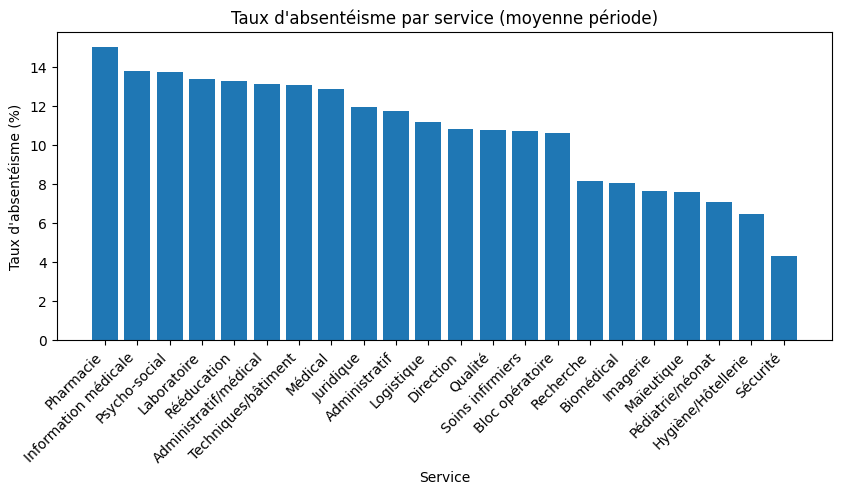

In [17]:
# Graphique 2 : comparaison par service (taux moyen sur la période)
fig, ax = plt.subplots(figsize=(10,4))
ax.bar(taux_par_service['catégorie'], taux_par_service['taux_absenteisme'])
ax.set_title('Taux d\'absentéisme par service (moyenne période)')
ax.set_ylabel('Taux d\'absentéisme (%)')
ax.set_xlabel('Service')
plt.xticks(rotation=45, ha='right')
plt.show()

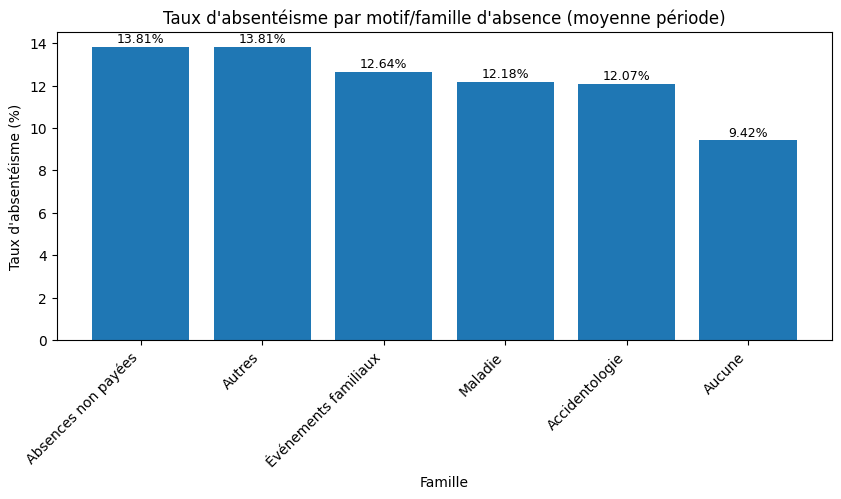

In [18]:
# Graphique 3 : comparaison par motif/famille d'absence (taux moyen sur la période)
fig, ax = plt.subplots(figsize=(10,4))
ax.bar(taux_par_famille['famille'], taux_par_famille['taux_absenteisme'])
ax.set_title('Taux d\'absentéisme par motif/famille d\'absence (moyenne période)')
ax.set_ylabel('Taux d\'absentéisme (%)')
ax.set_xlabel('Famille')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(taux_par_famille['taux_absenteisme']):
    ax.text(i, v + 0.2, f"{v:.2f}%", ha='center', fontsize=9)
plt.show()

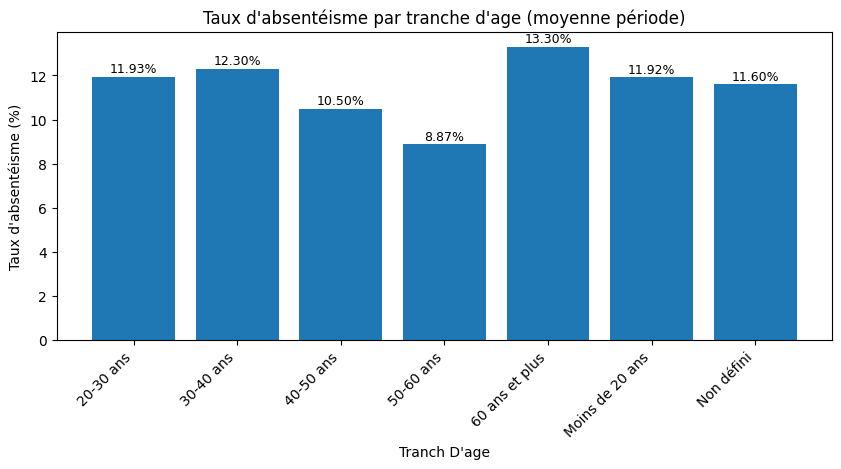

In [19]:
# Graphique 4 : comparaison par tranche d'age (taux moyen sur la période)
fig, ax = plt.subplots(figsize=(10,4))
ax.bar(taux_par_age['tranche_age'], taux_par_age['taux_absenteisme'])
ax.set_title('Taux d\'absentéisme par tranche d\'age (moyenne période)')
ax.set_ylabel('Taux d\'absentéisme (%)')
ax.set_xlabel('Tranch D\'age')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(taux_par_age['taux_absenteisme']):
    ax.text(i, v + 0.2, f"{v:.2f}%", ha='center', fontsize=9)
plt.show()

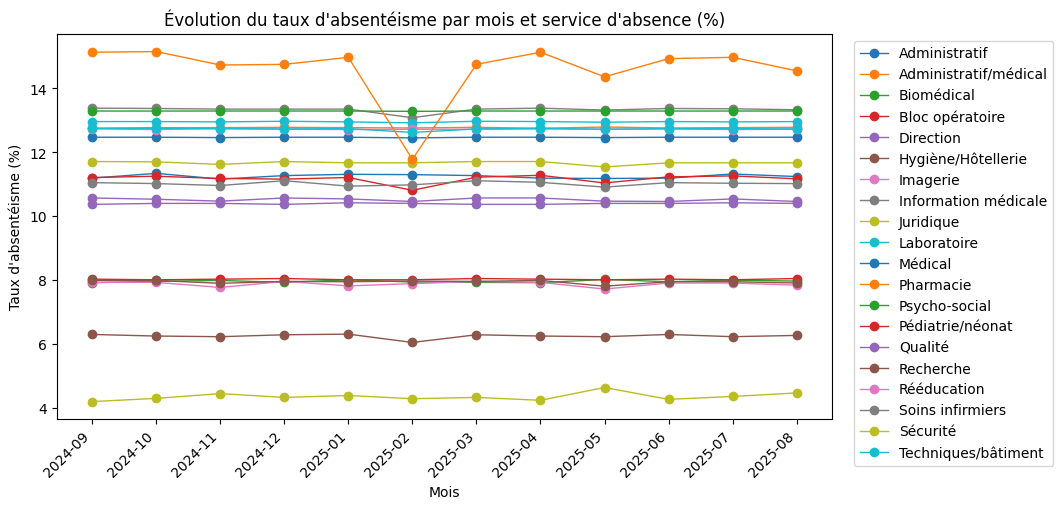

In [20]:
# Graphique 5 :  évolution du taux d’absentéisme de chaque service sur plusieurs mois
# Données (recréation du tableau croise service/mois)
tableau_croise = data = {
    'mois': ['2024-09','2024-10','2024-11','2024-12','2025-01','2025-02','2025-03','2025-04','2025-05','2025-06','2025-07','2025-08'],
    'Administratif': [11.19, 11.34, 11.16, 11.27, 11.31, 11.30, 11.27, 11.19, 11.18, 11.19, 11.32, 11.24],
    'Administratif/médical': [12.75, 12.77, 12.77, 12.78, 12.77, 12.76, 12.78, 12.75, 12.79, 12.76, 12.77, 12.78],
    'Biomédical': [7.92, 7.96, 7.99, 7.93, 8.01, 7.94, 7.93, 7.92, 8.02, 7.95, 8.00, 7.97],
    'Bloc opératoire': [11.21, 11.25, 11.18, 11.16, 11.21, 10.81, 11.22, 11.28, 11.04, 11.23, 11.26, 11.17],
    'Direction': [10.57, 10.53, 10.47, 10.57, 10.54, 10.46, 10.57, 10.57, 10.47, 10.46, 10.54, 10.46],
    'Hygiène/Hôtellerie': [6.30, 6.25, 6.23, 6.29, 6.31, 6.05, 6.29, 6.25, 6.23, 6.30, 6.23, 6.27],
    'Imagerie': [7.93, 7.93, 7.77, 7.96, 7.82, 7.89, 7.96, 7.93, 7.72, 7.91, 7.91, 7.84],
    'Information médicale': [13.38, 13.37, 13.35, 13.35, 13.35, 13.08, 13.35, 13.38, 13.32, 13.37, 13.36, 13.33],
    'Juridique': [11.71, 11.70, 11.62, 11.71, 11.67, 11.67, 11.71, 11.71, 11.54, 11.67, 11.67, 11.67],
    'Laboratoire': [12.96, 12.96, 12.95, 12.97, 12.95, 12.92, 12.97, 12.96, 12.94, 12.96, 12.95, 12.96],
    'Médical': [12.47, 12.47, 12.46, 12.47, 12.47, 12.45, 12.47, 12.47, 12.46, 12.47, 12.47, 12.47],
    'Pharmacie': [15.13, 15.15, 14.73, 14.75, 14.97, 11.78, 14.75, 15.13, 14.36, 14.93, 14.97, 14.55],
    'Psycho-social': [13.29, 13.29, 13.29, 13.29, 13.29, 13.28, 13.29, 13.29, 13.29, 13.29, 13.29, 13.29],
    'Pédiatrie/néonat': [8.03, 8.01, 8.03, 8.05, 8.01, 8.01, 8.05, 8.03, 8.01, 8.03, 8.01, 8.05],
    'Qualité': [10.37, 10.40, 10.40, 10.37, 10.42, 10.40, 10.37, 10.37, 10.40, 10.40, 10.42, 10.40],
    'Recherche': [7.99, 7.99, 7.90, 7.96, 7.95, 7.97, 7.96, 7.99, 7.81, 7.95, 7.95, 7.91],
    'Rééducation': [12.73, 12.71, 12.74, 12.72, 12.71, 12.72, 12.72, 12.73, 12.72, 12.73, 12.71, 12.72],
    'Soins infirmiers': [11.05, 11.02, 10.96, 11.11, 10.94, 10.98, 11.11, 11.06, 10.91, 11.05, 11.03, 11.02],
    'Sécurité': [4.20, 4.30, 4.45, 4.33, 4.39, 4.29, 4.33, 4.24, 4.64, 4.27, 4.36, 4.47],
    'Techniques/bâtiment': [12.75, 12.75, 12.74, 12.73, 12.74, 12.62, 12.73, 12.75, 12.72, 12.74, 12.74, 12.73]
}
df = pd.DataFrame(tableau_croise)
df = df.set_index('mois')

# Création du graphique
fig, ax = plt.subplots(figsize=(10,5))

for col in df.columns:
    ax.plot(df.index, df[col], marker='o', linewidth=1, label=col)

ax.set_title("Évolution du taux d'absentéisme par mois et service d'absence (%)")
ax.set_xlabel("Mois")
ax.set_ylabel("Taux d'absentéisme (%)")
ax.set_xticks(range(len(df.index)))
ax.set_xticklabels(df.index, rotation=45, ha='right')

# Légende
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.show()

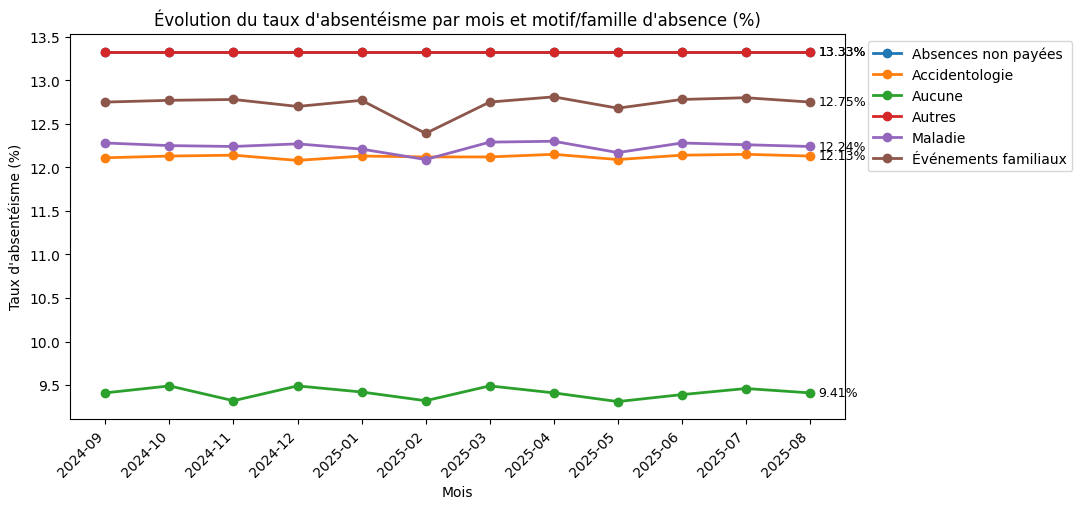

In [21]:
# Graphique 6 :  évolution du taux d’absentéisme de chaque motif/famille sur plusieurs mois
# Données (recréation du tableau croise famille/mois)
tableau_croise = {
    'mois': ['2024-09','2024-10','2024-11','2024-12','2025-01','2025-02','2025-03','2025-04','2025-05','2025-06','2025-07','2025-08'],
    'Absences non payées': [13.33]*12,
    'Accidentologie': [12.11,12.13,12.14,12.08,12.13,12.12,12.12,12.15,12.09,12.14,12.15,12.13],
    'Aucune': [9.41,9.49,9.32,9.49,9.42,9.32,9.49,9.41,9.31,9.39,9.46,9.41],
    'Autres': [13.33]*12,
    'Maladie': [12.28,12.25,12.24,12.27,12.21,12.09,12.29,12.30,12.17,12.28,12.26,12.24],
    'Événements familiaux': [12.75,12.77,12.78,12.70,12.77,12.39,12.75,12.81,12.68,12.78,12.80,12.75]
}
df = pd.DataFrame(tableau_croise)
df = df.set_index('mois')

# Création du graphique
fig, ax = plt.subplots(figsize=(10,5))

for col in df.columns:
    ax.plot(df.index, df[col], marker='o', linewidth=2, label=col)

ax.set_title("Évolution du taux d'absentéisme par mois et motif/famille d'absence (%)")
ax.set_xlabel("Mois")
ax.set_ylabel("Taux d'absentéisme (%)")
ax.set_xticks(range(len(df.index)))
ax.set_xticklabels(df.index, rotation=45, ha='right')

# Annoter la dernière valeur pour chaque famille
for col in df.columns:
    x = len(df.index) - 1
    y = df[col].iloc[-1]
    ax.annotate(f"{y:.2f}%", (x, y), textcoords="offset points", xytext=(6,0),
                va='center', fontsize=9)
# Légende
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.show()

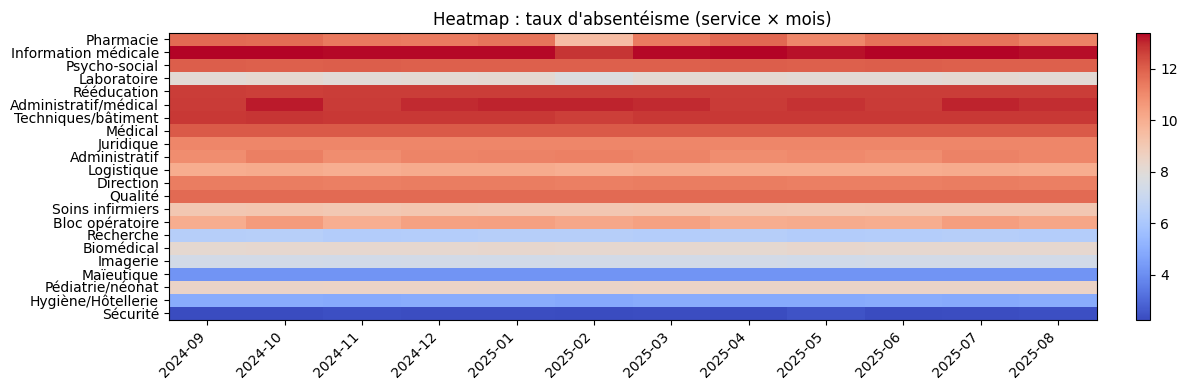

In [22]:
# Graphique 7 : heatmap mois x service (taux en %)
pivot = taux_absenteisme_data.pivot_table(index='catégorie', columns='mois', values='taux_absence', aggfunc='mean')
# Réordonner les services par taux moyen décroissant
order = taux_par_service['catégorie'].tolist()
pivot = pivot.reindex(order)
# Graphique
fig, ax = plt.subplots(figsize=(12,4))
im = ax.imshow(pivot, aspect='auto', cmap='coolwarm')
ax.set_title('Heatmap : taux d\'absentéisme (service × mois)')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.04)
plt.tight_layout()
plt.show()

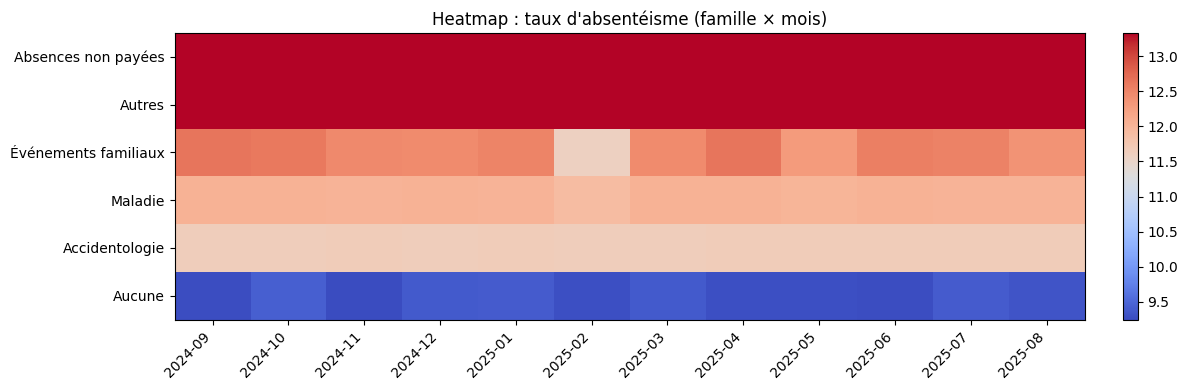

In [23]:
# Graphique 8 : heatmap mois x famille/type d'absence (taux en %)
pivot = taux_absenteisme_data.pivot_table(index='famille', columns='mois', values='taux_absence', aggfunc='mean')
# Réordonner les familles par taux moyen décroissant
order = taux_par_famille['famille'].tolist()
pivot = pivot.reindex(order)
# Graphique
fig, ax = plt.subplots(figsize=(12,4))
im = ax.imshow(pivot, aspect='auto', cmap='coolwarm')
ax.set_title('Heatmap : taux d\'absentéisme (famille × mois)')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.04)
plt.tight_layout()
plt.show()

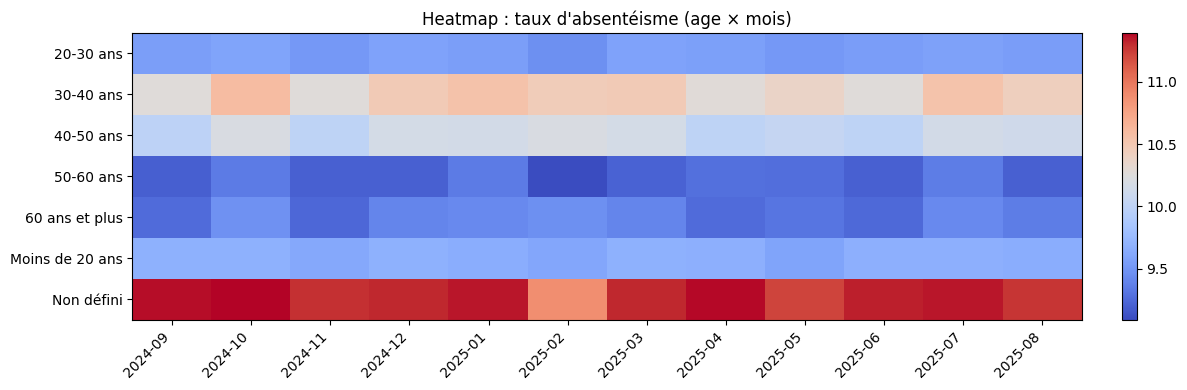

In [24]:
# Graphique 9 : heatmap mois x tranche d'age (taux en %)
pivot = taux_absenteisme_data.pivot_table(index='tranche_age', columns='mois', values='taux_absence', aggfunc='mean')
# Réordonner les tranches d'age par taux moyen décroissant
order = taux_par_age['tranche_age'].tolist()
pivot = pivot.reindex(order)
# Graphique
fig, ax = plt.subplots(figsize=(12,4))
im = ax.imshow(pivot, aspect='auto', cmap='coolwarm')
ax.set_title('Heatmap : taux d\'absentéisme (age × mois)')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.04)
plt.tight_layout()
plt.show()

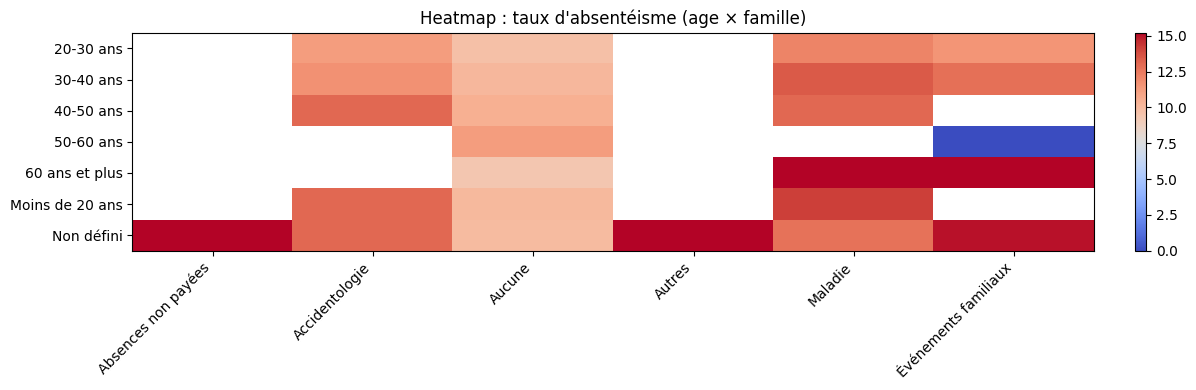

In [25]:
# Graphique 10 : heatmap famille x tranche d'age (taux en %)
pivot = taux_absenteisme_data.pivot_table(index='tranche_age', columns='famille', values='taux_absence', aggfunc='mean')
# Réordonner les tranches d'age par taux moyen décroissant
order = taux_par_age['tranche_age'].tolist()
pivot = pivot.reindex(order)
# Graphique
fig, ax = plt.subplots(figsize=(12,4))
im = ax.imshow(pivot, aspect='auto', cmap='coolwarm')
ax.set_title('Heatmap : taux d\'absentéisme (age × famille)')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.04)
plt.tight_layout()
plt.show()